<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%203/L06_SGD_and_Adaptive_Optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=9zYxWHU9Ick) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%203/NPTEL_Jul24_DL4CV_W03_P03.pdf)

In [1]:
# Week 3, Lecture 6: Gradient Descent Part 2
from IPython.display import HTML, display

VIDEO_ID = "9zYxWHU9Ick"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 3, Lecture 6: SGD and Adaptive Optimizers, Built From Scratch

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§3.3 Gradient Descent and Variants**.

We start from batch gradient descent and work outward to the adaptive optimizers
you use every day (Adagrad, RMSProp, Adam), coding every update rule by hand and
watching it move on a loss surface.

**What you will learn**
- The three update regimes: batch GD, stochastic GD (SGD), and mini-batch SGD,
  implemented from scratch, and why SGD is noisier but faster.
- Learning rate schedules (step, exponential, 1/t decay) as plain functions of
  the iteration, plus one applied to training.
- Adagrad, RMSProp, and Adam coded exactly as the slide equations, compared
  against plain SGD and momentum on a shared ill-conditioned surface.
- A sanity check with `torch.optim.SGD` and `torch.optim.Adam` that confirms the
  from-scratch intuition on a tiny network.

**How we build it**
From-scratch update rules first (plain numpy and torch tensors), so you see every
term, then the idiomatic `torch.optim` version at the end to confirm they agree.

**How to run**   Colab CPU or GPU, or a local Jupyter. Every dataset is tiny
and every cell finishes in a few seconds on CPU. Run the setup cell first.

**Contents**

1. Batch GD vs SGD vs Mini-batch SGD
2. Choosing the learning rate
3. Adaptive optimizers, coded from scratch
4. Sanity check with torch.optim

## Review

The previous lecture added momentum and Nesterov acceleration to plain gradient descent and watched them cross an ill-conditioned ravine. Both still use the whole dataset for every step. This lecture changes what each step *sees*, then makes the learning rate adapt per parameter.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and local Jupyter.
import sys, subprocess
# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, FloatSlider, IntSlider, Dropdown, Checkbox, fixed
%matplotlib inline

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Use a GPU if one is available, otherwise CPU. Every demo here is tiny and
# runs in seconds on CPU, so no GPU is required.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.8.0 | device: cpu


## 1. Batch GD vs SGD vs Mini-batch SGD

All three minimize the same cost by stepping downhill, using the same update

$$\theta_{t+1} = \theta_t - \alpha\, \Delta\theta_t, \qquad \Delta\theta_t = \nabla_\theta L.$$

They differ only in **how much data** each update uses.

- **Batch GD.** Compute the gradient over the entire dataset, then take one step.
  - Pros: conditions of convergence are well understood; batch acceleration tricks
    (for example conjugate gradient) apply.
  - Cons: one step needs a full pass, which is painfully slow on large data. A
    single pass over ImageNet (about 14.2 million images) per update is a non-starter.
- **Stochastic GD (SGD).** Shuffle the data and update after **each** example.
  Cheap and fast; the update noise can even help escape local minima and saddle
  points. The cost is a noisy path that may not settle without a good learning rate.
- **Mini-batch SGD.** Update after a small batch of $m$ examples (aggregate the
  gradient over the batch, then step). This is the default today and is usually
  just called "SGD". Less noisy than $m = 1$, still far more updates per pass than
  batch GD.

We fit a bias-free logistic regression (two weights $w_1, w_2$, so the parameter
path is 2D and easy to plot) on two Gaussian blobs, and run all three regimes
from scratch: an inner loop over the full data, single examples, or mini-batches.

In [3]:
from sklearn.datasets import make_blobs

# Two Gaussian blobs, a tiny binary classification set. We center the features so
# a bias-free logistic model is enough, keeping the parameter vector 2D (w1, w2).
N = 300
Xnp, ynp = make_blobs(n_samples=N, centers=[[-2.0, -2.0], [2.0, 2.0]],
                      cluster_std=1.4, random_state=0)
Xnp = Xnp - Xnp.mean(axis=0, keepdims=True)
ynp = ynp.astype(np.float32)

X = torch.tensor(Xnp, dtype=torch.float32, device=device)
y = torch.tensor(ynp, dtype=torch.float32, device=device)

def full_loss(w):
    "Mean binary cross entropy over the whole dataset (no bias term)."
    with torch.no_grad():
        return F.binary_cross_entropy_with_logits(X @ w, y).item()

def train_regime(batch_size, lr=0.5, epochs=12, seed=0):
    "One from-scratch training run. batch_size = N is batch GD, 1 is SGD."
    g = torch.Generator().manual_seed(seed)
    w = torch.zeros(2, device=device, requires_grad=True)
    updates_per_epoch = int(np.ceil(N / batch_size))
    loss_hist, traj = [], []
    for _ in range(epochs):
        perm = torch.randperm(N, generator=g).to(device)   # shuffle each epoch
        for start in range(0, N, batch_size):
            idx = perm[start:start + batch_size]            # full data / 1 / m rows
            loss = F.binary_cross_entropy_with_logits(X[idx] @ w, y[idx])
            loss.backward()                                 # delta_theta = grad L
            with torch.no_grad():
                w -= lr * w.grad                            # theta <- theta - alpha*grad
                w.grad.zero_()
            loss_hist.append(full_loss(w))
            traj.append(w.detach().cpu().numpy().copy())
    # x-axis in epochs so all regimes are comparable per pass over the data.
    xs = np.arange(1, len(loss_hist) + 1) / updates_per_epoch
    return xs, np.array(loss_hist), np.array(traj)

print("dataset:", tuple(X.shape), "points, classes:", np.unique(ynp))

dataset: (300, 2) points, classes: [0. 1.]


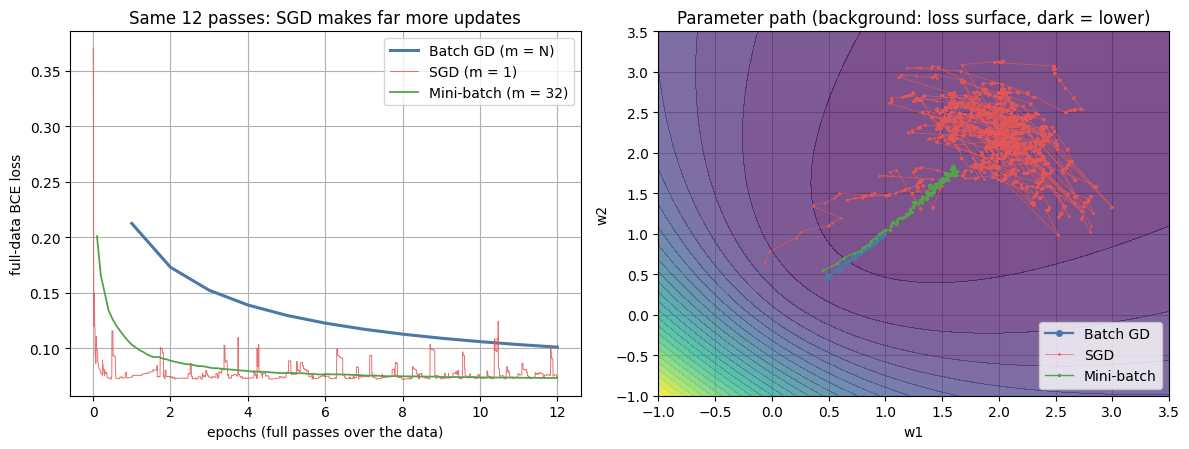

final full-data loss:  batch 0.1011   SGD 0.0745   mini-batch 0.0734


In [4]:
# Loss surface over the two weights, used as the background for the trajectory.
gw = np.linspace(-1.0, 3.5, 70)
w1g, w2g = np.meshgrid(gw, gw)
logit_grid = w1g[..., None] * Xnp[:, 0] + w2g[..., None] * Xnp[:, 1]   # (70,70,N)
Z = np.mean(np.logaddexp(0.0, logit_grid) - ynp * logit_grid, axis=-1)  # mean BCE

# Same number of passes (epochs) over the data for a fair comparison.
xb, lb, tb = train_regime(N,  lr=0.5, epochs=12)   # Batch GD: 1 update per epoch
xs, ls, ts = train_regime(1,  lr=0.5, epochs=12)   # SGD: N updates per epoch
xm, lm, tm = train_regime(32, lr=0.5, epochs=12)   # Mini-batch: m = 32

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))
axL.plot(xb, lb, color="#4c78a8", lw=2.2, label="Batch GD (m = N)")
axL.plot(xs, ls, color="#e45756", lw=0.7, alpha=0.85, label="SGD (m = 1)")
axL.plot(xm, lm, color="#54a24b", lw=1.3, label="Mini-batch (m = 32)")
axL.set_xlabel("epochs (full passes over the data)")
axL.set_ylabel("full-data BCE loss")
axL.set_title("Same 12 passes: SGD makes far more updates")
axL.legend()

axR.contourf(w1g, w2g, Z, levels=25, cmap="viridis", alpha=0.7)
axR.plot(tb[:, 0], tb[:, 1], "o-", color="#4c78a8", ms=4, lw=1.7, label="Batch GD")
axR.plot(ts[:, 0], ts[:, 1], ".-", color="#e45756", ms=2, lw=0.5, alpha=0.85, label="SGD")
axR.plot(tm[:, 0], tm[:, 1], ".-", color="#54a24b", ms=3, lw=1.0, label="Mini-batch")
axR.set_xlabel("w1")
axR.set_ylabel("w2")
axR.set_title("Parameter path (background: loss surface, dark = lower)")
axR.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("final full-data loss:  batch %.4f   SGD %.4f   mini-batch %.4f" %
      (lb[-1], ls[-1], lm[-1]))

### Widget: batch size controls the noise

Slide the batch size $m$ from 1 (pure SGD, noisiest) up to $N$ (full batch GD,
smoothest). Watch the loss curve get noisier and the parameter path get more
jagged as $m$ shrinks, while small batches still make rapid progress because they
take many updates per pass.

In [5]:
def batch_size_demo(batch_size=32):
    xs_, ls_, traj = train_regime(batch_size, lr=0.5, epochs=10)
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))
    axL.plot(xs_, ls_, color="#e45756", lw=0.9)
    axL.set_xlabel("epochs (full passes over the data)")
    axL.set_ylabel("full-data BCE loss")
    axL.set_title("Loss curve, batch size m = %d" % batch_size)
    axL.set_ylim(0.0, 0.75)
    axR.contourf(w1g, w2g, Z, levels=25, cmap="viridis", alpha=0.7)
    axR.plot(traj[:, 0], traj[:, 1], ".-", color="crimson", ms=3, lw=0.7)
    axR.set_xlabel("w1")
    axR.set_ylabel("w2")
    axR.set_title("Parameter path noise at m = %d (%d updates)" % (batch_size, len(traj)))
    plt.tight_layout()
    plt.show()

interact(batch_size_demo,
         batch_size=IntSlider(min=1, max=N, step=1, value=32));

interactive(children=(IntSlider(value=32, description='batch_size', max=300, min=1), Output()), _dom_classes=(…

## 2. Choosing the learning rate

SGD lives or dies by its learning rate $\alpha$. Too small and it crawls; too
large and the gradients explode. A constant $\alpha$ (naive linear search) is the
simplest choice, but annealing $\alpha$ over time usually helps: take large steps
early, then small careful steps near the minimum.

Three common schedules, as functions of the iteration $t$:

- **Step decay**: cut $\alpha$ by a fixed factor every few iterations or epochs.
- **Exponential decay**: $\alpha = \alpha_0\, e^{-k t}$.
- **1/t decay**: $\displaystyle \alpha = \frac{\alpha_0}{1 + k t}$.

Here $\alpha_0$ is the starting rate and $k$ is a decay hyperparameter.

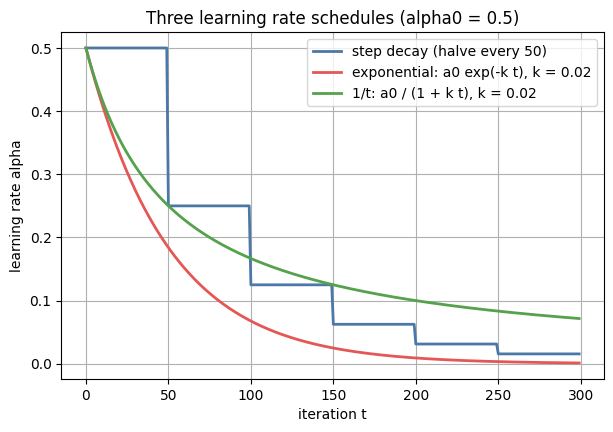

In [6]:
def step_decay(t, a0=0.5, drop=0.5, every=50):
    "Step decay: multiply the LR by 'drop' every 'every' iterations."
    return a0 * (drop ** np.floor(t / every))

def exp_decay(t, a0=0.5, k=0.02):
    "Exponential decay: alpha = alpha0 * exp(-k t)."
    return a0 * np.exp(-k * t)

def inv_t_decay(t, a0=0.5, k=0.02):
    "1/t decay: alpha = alpha0 / (1 + k t)."
    return a0 / (1.0 + k * t)

t = np.arange(0, 300)
plt.figure()
plt.plot(t, step_decay(t),            color="#4c78a8", lw=2, label="step decay (halve every 50)")
plt.plot(t, exp_decay(t, k=0.02),     color="#e45756", lw=2, label="exponential: a0 exp(-k t), k = 0.02")
plt.plot(t, inv_t_decay(t, k=0.02),   color="#54a24b", lw=2, label="1/t: a0 / (1 + k t), k = 0.02")
plt.xlabel("iteration t")
plt.ylabel("learning rate alpha")
plt.title("Three learning rate schedules (alpha0 = 0.5)")
plt.legend()
plt.show()

### Widget: pick a schedule and its decay rate

Choose the schedule and drag the decay rate $k$ (which controls the exponential
and 1/t curves; step decay uses its own fixed drop). Larger $k$ means a faster
decay.

In [7]:
def schedule_demo(schedule="exponential", k=0.02):
    t = np.arange(0, 300)
    if schedule == "step":
        a = step_decay(t)
    elif schedule == "exponential":
        a = exp_decay(t, k=k)
    else:
        a = inv_t_decay(t, k=k)
    plt.figure()
    plt.plot(t, a, color="#e45756", lw=2.2)
    plt.xlabel("iteration t")
    plt.ylabel("learning rate alpha")
    plt.title("%s schedule (k = %.3f, alpha0 = 0.5)" % (schedule, k))
    plt.ylim(0.0, 0.55)
    plt.show()

interact(schedule_demo,
         schedule=Dropdown(options=["step", "exponential", "1/t"], value="exponential"),
         k=FloatSlider(min=0.001, max=0.1, step=0.001, value=0.02));

interactive(children=(Dropdown(description='schedule', index=1, options=('step', 'exponential', '1/t'), value=…

### One schedule applied to training

A constant, largish learning rate keeps pure SGD bouncing around the minimum
forever (the loss has a noisy floor). Decaying the same starting rate lets the
steps shrink so the run settles into a lower, quieter loss. We print the standard
deviation of the last 100 loss values to make the difference concrete.

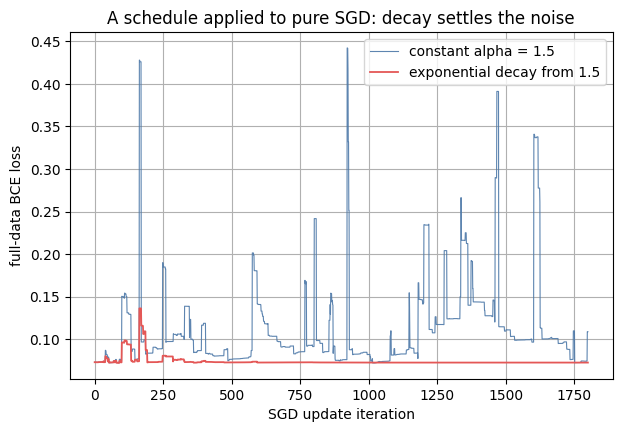

std of last 100 losses:  constant = 0.0120   decayed = 0.0000


In [8]:
def train_with_schedule(sched_fn, batch_size=1, epochs=6, seed=1):
    "Pure SGD (m = 1) where the learning rate at iteration t is sched_fn(t)."
    g = torch.Generator().manual_seed(seed)
    w = torch.zeros(2, device=device, requires_grad=True)
    losses, it = [], 0
    for _ in range(epochs):
        perm = torch.randperm(N, generator=g).to(device)
        for start in range(0, N, batch_size):
            idx = perm[start:start + batch_size]
            loss = F.binary_cross_entropy_with_logits(X[idx] @ w, y[idx])
            loss.backward()
            lr_t = float(sched_fn(it))
            with torch.no_grad():
                w -= lr_t * w.grad
                w.grad.zero_()
            losses.append(full_loss(w))
            it += 1
    return np.array(losses)

const_hist = train_with_schedule(lambda t: 1.5)
decay_hist = train_with_schedule(lambda t: exp_decay(t, a0=1.5, k=0.005))

plt.figure()
plt.plot(const_hist, color="#4c78a8", lw=0.8, alpha=0.9, label="constant alpha = 1.5")
plt.plot(decay_hist, color="#e45756", lw=1.3, label="exponential decay from 1.5")
plt.xlabel("SGD update iteration")
plt.ylabel("full-data BCE loss")
plt.title("A schedule applied to pure SGD: decay settles the noise")
plt.legend()
plt.show()

print("std of last 100 losses:  constant = %.4f   decayed = %.4f" %
      (const_hist[-100:].std(), decay_hist[-100:].std()))

## 3. Adaptive optimizers, coded from scratch

A single global learning rate is a blunt instrument: sparse or low-curvature
directions want a bigger step than steep ones. Adaptive methods give **each
parameter its own effective learning rate**, derived from the history of its
gradients. We implement each update exactly as the slides state, with a small
constant $\delta$ for numeric stability.

**Adagrad** (accumulate squared gradients; steep directions get damped):

$$r_t = r_{t-1} + (\Delta\theta_t)^2, \qquad
\theta_{t+1} = \theta_t - \frac{\alpha}{\delta + \sqrt{r_t}}\, \Delta\theta_t.$$

Per-parameter and adaptive, but $r_t$ only grows, so the effective step decays
toward zero and learning can stall.

**RMSProp** (fix Adagrad's vanishing step with an exponentially decaying average):

$$r_t = \rho\, r_{t-1} + (1 - \rho)(\Delta\theta_t)^2, \qquad
\theta_{t+1} = \theta_t - \frac{\alpha}{\delta + \sqrt{r_t}}\, \Delta\theta_t.$$

**Adam** (combine momentum with RMSProp, plus bias correction):

$$s_t = \rho_1 s_{t-1} + (1 - \rho_1)\,\Delta\theta_t, \qquad
r_t = \rho_2 r_{t-1} + (1 - \rho_2)(\Delta\theta_t)^2,$$

$$\hat{s}_t = \frac{s_t}{1 - \rho_1^{\,t}}, \qquad
\hat{r}_t = \frac{r_t}{1 - \rho_2^{\,t}}, \qquad
\theta_{t+1} = \theta_t - \alpha\, \frac{\hat{s}_t}{\delta + \sqrt{\hat{r}_t}}.$$

The bias correction matters early, when $s_t$ and $r_t$ are still pulled toward
their zero initial values. We also include plain **momentum**
($v_t = \mu v_{t-1} + \Delta\theta_t$, then $\theta_{t+1} = \theta_t - \alpha v_t$)
and plain **SGD** for comparison. The test surface is an ill-conditioned quadratic
bowl, $f(x, y) = \tfrac{1}{2}(10 x^2 + y^2)$: steep in $x$, shallow in $y$. Plain
SGD zig-zags across the steep direction while crawling along the shallow one; the
adaptive methods rescale per direction.

In [9]:
# An ill-conditioned quadratic bowl: curvature 10 in x, 1 in y (condition number 10).
Acurv = np.array([10.0, 1.0])

def f_surface(theta):
    "Loss f(theta) = 0.5 (10 x^2 + y^2)."
    return 0.5 * float(Acurv[0] * theta[0] ** 2 + Acurv[1] * theta[1] ** 2)

def grad_surface(theta):
    "Gradient of f: (10 x, y)."
    return Acurv * theta

def run_optimizer(name, lr, n_steps=80, start=(-4.0, 4.0),
                  mu=0.85, rho=0.9, rho1=0.9, rho2=0.999, delta=1e-8):
    "From-scratch optimizer, each branch matching the slide update equations."
    theta = np.array(start, dtype=np.float64)
    v = np.zeros(2); acc = np.zeros(2); r = np.zeros(2); s = np.zeros(2)
    traj = [theta.copy()]
    losses = [f_surface(theta)]
    for t in range(1, n_steps + 1):
        g = grad_surface(theta)                          # delta_theta_t = grad L
        if name == "SGD":
            theta = theta - lr * g
        elif name == "Momentum":
            v = mu * v + g
            theta = theta - lr * v
        elif name == "Adagrad":
            acc = acc + g ** 2                           # r_t = r_{t-1} + g^2
            theta = theta - lr / (delta + np.sqrt(acc)) * g
        elif name == "RMSProp":
            r = rho * r + (1 - rho) * g ** 2             # r_t = rho r + (1-rho) g^2
            theta = theta - lr / (delta + np.sqrt(r)) * g
        elif name == "Adam":
            s = rho1 * s + (1 - rho1) * g                # first moment
            r = rho2 * r + (1 - rho2) * g ** 2           # second moment
            s_hat = s / (1 - rho1 ** t)                  # bias correction
            r_hat = r / (1 - rho2 ** t)
            theta = theta - lr * s_hat / (delta + np.sqrt(r_hat))
        traj.append(theta.copy())
        losses.append(f_surface(theta))
    return np.array(traj), np.array(losses)

# Note: the slides use slightly different delta per method (about 1e-7 for Adagrad,
# 1e-6 for RMSProp, 1e-8 for Adam). One small delta is fine for this demo.
print("surface ready:  f(x, y) = 0.5 (10 x^2 + y^2), minimum at (0, 0)")

surface ready:  f(x, y) = 0.5 (10 x^2 + y^2), minimum at (0, 0)


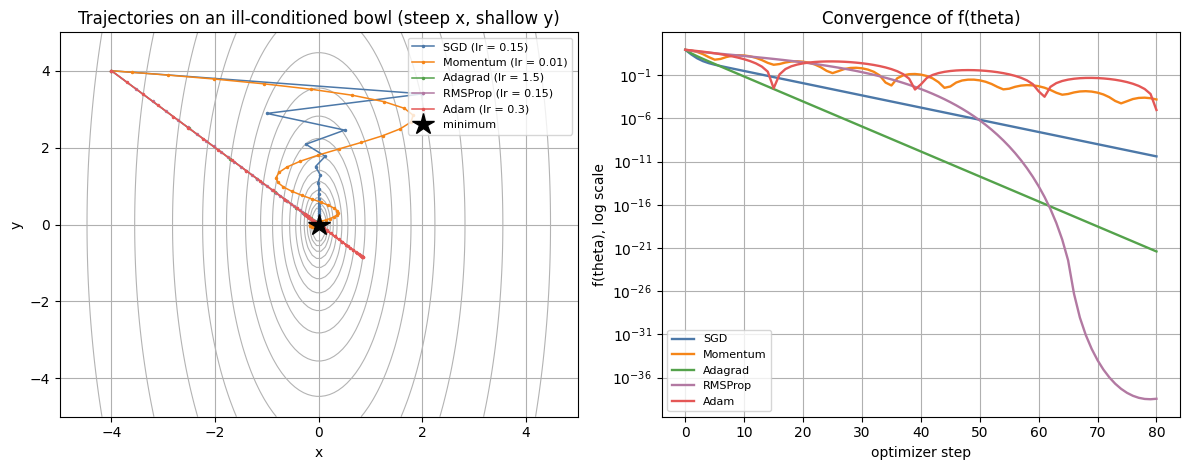

In [10]:
# Contour background for all section 3 plots.
gg = np.linspace(-5, 5, 120)
GX, GY = np.meshgrid(gg, gg)
GZ = 0.5 * (Acurv[0] * GX ** 2 + Acurv[1] * GY ** 2)
contour_levels = np.logspace(-1, 2.4, 18)

settings = [
    ("SGD",      0.15, "#4c78a8"),
    ("Momentum", 0.01, "#f58518"),
    ("Adagrad",  1.50, "#54a24b"),
    ("RMSProp",  0.15, "#b279a2"),
    ("Adam",     0.30, "#e45756"),
]

fig, (axT, axC) = plt.subplots(1, 2, figsize=(12, 4.8))
axT.contour(GX, GY, GZ, levels=contour_levels, colors="0.7", linewidths=0.8)
for name, lr, col in settings:
    traj, loss = run_optimizer(name, lr)
    axT.plot(traj[:, 0], traj[:, 1], ".-", color=col, ms=3, lw=1.1,
             label="%s (lr = %g)" % (name, lr))
    axC.plot(loss, color=col, lw=1.7, label=name)
axT.plot(0, 0, "k*", ms=16, label="minimum")
axT.set_xlim(-5, 5)
axT.set_ylim(-5, 5)
axT.set_xlabel("x")
axT.set_ylabel("y")
axT.set_title("Trajectories on an ill-conditioned bowl (steep x, shallow y)")
axT.legend(fontsize=8, loc="upper right")
axC.set_yscale("log")
axC.set_xlabel("optimizer step")
axC.set_ylabel("f(theta), log scale")
axC.set_title("Convergence of f(theta)")
axC.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Widget: optimizer and learning rate

Pick an optimizer and a learning rate and watch its path on the bowl and its
convergence curve. Things to try: push SGD's learning rate up until it diverges;
give Adagrad a large rate and watch it slow down on its own; see how Adam and
RMSProp stay stable across a wide range.

In [11]:
def optimizer_demo(optimizer="Adam", lr=0.3):
    traj, loss = run_optimizer(optimizer, lr, n_steps=80)
    fig, (axT, axC) = plt.subplots(1, 2, figsize=(12, 4.8))
    axT.contour(GX, GY, GZ, levels=contour_levels, colors="0.7", linewidths=0.8)
    axT.plot(traj[:, 0], traj[:, 1], ".-", color="#e45756", ms=4, lw=1.2)
    axT.plot(0, 0, "k*", ms=16)
    axT.set_xlim(-5, 5)
    axT.set_ylim(-5, 5)
    axT.set_xlabel("x")
    axT.set_ylabel("y")
    axT.set_title("%s trajectory (lr = %.3f)" % (optimizer, lr))
    finite = np.isfinite(loss)
    axC.plot(np.arange(len(loss))[finite], np.clip(loss[finite], 1e-12, None),
             color="#e45756", lw=1.8)
    axC.set_yscale("log")
    axC.set_xlabel("optimizer step")
    axC.set_ylabel("f(theta), log scale")
    axC.set_title("Convergence (final f = %.2e)" % loss[-1])
    plt.tight_layout()
    plt.show()

interact(optimizer_demo,
         optimizer=Dropdown(options=["SGD", "Momentum", "Adagrad", "RMSProp", "Adam"], value="Adam"),
         lr=FloatSlider(min=0.005, max=1.5, step=0.005, value=0.3));

interactive(children=(Dropdown(description='optimizer', index=4, options=('SGD', 'Momentum', 'Adagrad', 'RMSPr…

### Widget: Adam's momentum terms

$\beta_1$ (called $\rho_1$ on the slide) controls the first-moment (momentum)
average; $\beta_2$ ($\rho_2$) controls the second-moment (RMSProp) average. The
defaults 0.9 and 0.999 are the usual starting point. A lower $\beta_2$ makes the
per-parameter scaling react faster but noisier.

In [12]:
def adam_moments_demo(beta1=0.9, beta2=0.999):
    traj, loss = run_optimizer("Adam", lr=0.3, n_steps=80, rho1=beta1, rho2=beta2)
    fig, (axT, axC) = plt.subplots(1, 2, figsize=(12, 4.8))
    axT.contour(GX, GY, GZ, levels=contour_levels, colors="0.7", linewidths=0.8)
    axT.plot(traj[:, 0], traj[:, 1], ".-", color="#54a24b", ms=4, lw=1.2)
    axT.plot(0, 0, "k*", ms=16)
    axT.set_xlim(-5, 5)
    axT.set_ylim(-5, 5)
    axT.set_xlabel("x")
    axT.set_ylabel("y")
    axT.set_title("Adam with beta1 = %.3f, beta2 = %.4f" % (beta1, beta2))
    axC.plot(np.clip(loss, 1e-12, None), color="#54a24b", lw=1.8)
    axC.set_yscale("log")
    axC.set_xlabel("optimizer step")
    axC.set_ylabel("f(theta), log scale")
    axC.set_title("Convergence (final f = %.2e)" % loss[-1])
    plt.tight_layout()
    plt.show()

interact(adam_moments_demo,
         beta1=FloatSlider(min=0.5, max=0.99, step=0.01, value=0.9),
         beta2=FloatSlider(min=0.90, max=0.9999, step=0.0001, value=0.999));

interactive(children=(FloatSlider(value=0.9, description='beta1', max=0.99, min=0.5, step=0.01), FloatSlider(v…

## 4. Sanity check with torch.optim

Everything above was hand-coded; in practice you call
`torch.optim`, which implements these exact update rules. We train one tiny
2-layer MLP on make_moons twice, once with `torch.optim.SGD` and once with
`torch.optim.Adam`, from the same initial weights, and compare the loss curves.

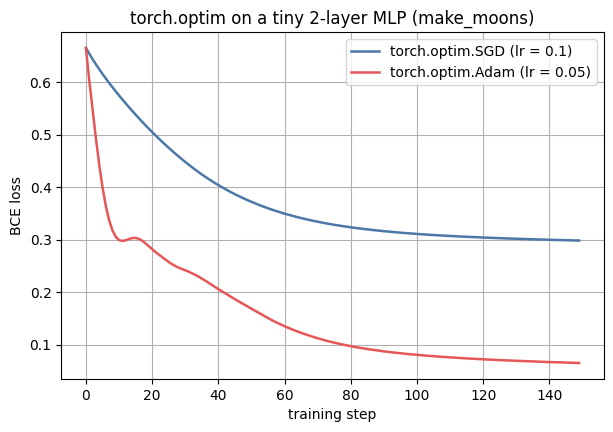

final loss:  SGD = 0.2983   Adam = 0.0651
Adam's fast early descent matches the from-scratch intuition from section 3.


In [13]:
from sklearn.datasets import make_moons

Xmoon, ymoon = make_moons(n_samples=200, noise=0.2, random_state=0)
Xmoon = (Xmoon - Xmoon.mean(axis=0)) / Xmoon.std(axis=0)      # standardize
Xmoon_t = torch.tensor(Xmoon, dtype=torch.float32, device=device)
ymoon_t = torch.tensor(ymoon, dtype=torch.float32, device=device).unsqueeze(1)

def build_mlp(seed=0):
    "A tiny 2-16-1 MLP (same init every time we pass the same seed)."
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1)).to(device)

def train_with_optim(kind, lr, steps=150):
    "Full-batch training with a real torch.optim optimizer. Returns loss history."
    model = build_mlp(seed=0)
    if kind == "SGD":
        opt = torch.optim.SGD(model.parameters(), lr=lr)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    hist = []
    for _ in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(Xmoon_t), ymoon_t)
        loss.backward()      # autograd computes the gradients
        opt.step()           # the optimizer applies exactly the rules from section 3
        hist.append(loss.item())
    return hist

hist_sgd = train_with_optim("SGD", lr=0.1)
hist_adam = train_with_optim("Adam", lr=0.05)

plt.figure()
plt.plot(hist_sgd,  color="#4c78a8", lw=1.8, label="torch.optim.SGD (lr = 0.1)")
plt.plot(hist_adam, color="#e45756", lw=1.8, label="torch.optim.Adam (lr = 0.05)")
plt.xlabel("training step")
plt.ylabel("BCE loss")
plt.title("torch.optim on a tiny 2-layer MLP (make_moons)")
plt.legend()
plt.show()

print("final loss:  SGD = %.4f   Adam = %.4f" % (hist_sgd[-1], hist_adam[-1]))
print("Adam's fast early descent matches the from-scratch intuition from section 3.")

## Training neural nets with SGD: the challenges

Real loss surfaces are non-convex, high-dimensional, and full of traps that make
gradient descent hard:

- Plateaus and flat regions where gradients are tiny.
- Local minima and saddle points.
- Vanishing and exploding gradients (and sharp cliffs).
- Ill-conditioning (the steep versus shallow problem from section 3).
- Inexact gradients and a poor match between local and global structure.
- Choosing the learning rate and other hyperparameters.

There are no strong guarantees that training converges to a good solution, quickly,
or at all. And yet, with the tools in this notebook, **it works** remarkably well
in practice.

## Key takeaways

- Batch GD, SGD, and mini-batch SGD use the same step
  $\theta_{t+1} = \theta_t - \alpha\,\Delta\theta_t$; they differ only in how much
  data feeds each update. Mini-batch SGD (small $m$) is the practical default.
- SGD's noise is both a feature and a bug: it speeds things up and can escape
  saddles, but needs a sensible learning rate (often a decay schedule) to settle.
- Schedules: step, exponential $\alpha_0 e^{-k t}$, and 1/t $\alpha_0 / (1 + k t)$.
- Adaptive methods give each parameter its own step size from its gradient history:
  Adagrad accumulates $g^2$ (and stalls), RMSProp decays that accumulator (no
  stall), and Adam adds momentum plus bias correction.
- `torch.optim.SGD` and `torch.optim.Adam` are exactly the from-scratch rules you
  coded here, just batteries included.

## Exercises

- Answer the slide's question: how could you tell whether you are stuck at a local
  minimum versus a saddle point on the loss surface? (Hint: think about the
  curvature, that is the eigenvalues of the Hessian.)
- Change the surface in section 3 to a steeper condition number (say $50 x^2 + y^2$)
  and re-tune each optimizer. Which methods still work at the same learning rate?
- Read DL Book Chapter 8 and the cs231n notes on SGD linked in the lecture.